# Modelisation

In [45]:
import numpy as np
import pandas as pd
import gc
import time
from contextlib import contextmanager
from lightgbm import LGBMClassifier
from sklearn.metrics import roc_auc_score, roc_curve
from sklearn.model_selection import KFold, StratifiedKFold
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.simplefilter(action='ignore', category=FutureWarning)
# File system management
import os
import pickle
import dill
from collections import Counter
# Scikit-learn
from sklearn.model_selection import cross_val_predict, cross_validate, cross_val_score, train_test_split
from sklearn.model_selection import GridSearchCV, StratifiedKFold, RepeatedStratifiedKFold
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.impute import SimpleImputer
from sklearn.metrics import roc_curve, roc_auc_score, f1_score, accuracy_score, classification_report
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
from sklearn.metrics import make_scorer
from sklearn.preprocessing import StandardScaler
# XGBoost
import xgboost as xgb
# LightGBM
import lightgbm as ltb
# Balancing data
from imblearn.over_sampling import SMOTE
from imblearn.under_sampling import RandomUnderSampler
from imblearn.pipeline import Pipeline as ImbPipeline
from sklearn.model_selection import GridSearchCV
from sklearn.metrics import (make_scorer, accuracy_score, precision_score, recall_score, f1_score, roc_auc_score,
    average_precision_score, classification_report,confusion_matrix)
from sklearn.model_selection import StratifiedKFold, cross_validate
from sklearn.metrics import precision_score
import mlflow
import mlflow.sklearn

In [27]:
pd.set_option('display.max_row', 20)
pd.set_option('display.max_columns', 50)
pd.set_option('display.width', 500)

In [28]:
@contextmanager
def timer(title):
    t0 = time.time()
    yield
    print("{} - done in {:.0f}s".format(title, time.time() - t0))

# Import des bases de données

In [29]:
df = pd.read_csv('data.csv', nrows=None)
#df = pd.read_parquet("data.parquet")
df.shape

(356251, 463)

In [30]:
# Conversion des floats 64 → float32
float_cols = df.select_dtypes(include=["float64"]).columns
df[float_cols] = df[float_cols].astype("float32")

# Conversion des int 64 → int32
int_cols = df.select_dtypes(include=["int64"]).columns
df[int_cols] = df[int_cols].astype("int32")

# Conversion des bool → int8 (suffisant et plus léger)
bool_cols = df.select_dtypes(include=["bool"]).columns
df[bool_cols] = df[bool_cols].astype("int8")

In [31]:
# Interpratability

import shap

%matplotlib inline
sns.set_theme(palette="Set1")

In [32]:
df = df.replace([np.inf, -np.inf], np.nan)

# Split du dataset

In [9]:
df.shape

(356251, 463)

In [33]:
# Define usefull variables
TARGET = 'TARGET'
ID = 'SK_ID_CURR'

In [34]:
# === Split train / test avant tout ===
train_df = df[df['TARGET'].notna()].copy()
test_df  = df[df['TARGET'].isna()].copy()


In [35]:
display(test_df.head())
display(train_df.head())

,Unnamed: 0,SK_ID_CURR,TARGET,CODE_GENDER,FLAG_OWN_CAR,FLAG_OWN_REALTY,CNT_CHILDREN,AMT_INCOME_TOTAL,AMT_CREDIT,AMT_ANNUITY,REGION_POPULATION_RELATIVE,DAYS_BIRTH,DAYS_EMPLOYED,DAYS_REGISTRATION,DAYS_ID_PUBLISH,FLAG_WORK_PHONE,FLAG_PHONE,FLAG_EMAIL,CNT_FAM_MEMBERS,REGION_RATING_CLIENT,HOUR_APPR_PROCESS_START,REG_REGION_NOT_LIVE_REGION,REG_REGION_NOT_WORK_REGION,LIVE_REGION_NOT_WORK_REGION,REG_CITY_NOT_LIVE_CITY,...,INSTAL_DPD_MAX,INSTAL_DPD_MEAN,INSTAL_DPD_SUM,INSTAL_DBD_MAX,INSTAL_DBD_MEAN,INSTAL_DBD_SUM,INSTAL_PAYMENT_PERC_MAX,INSTAL_PAYMENT_PERC_MEAN,INSTAL_PAYMENT_PERC_SUM,INSTAL_PAYMENT_PERC_VAR,INSTAL_PAYMENT_DIFF_MAX,INSTAL_PAYMENT_DIFF_MEAN,INSTAL_PAYMENT_DIFF_SUM,INSTAL_PAYMENT_DIFF_VAR,INSTAL_AMT_INSTALMENT_MAX,INSTAL_AMT_INSTALMENT_MEAN,INSTAL_AMT_INSTALMENT_SUM,INSTAL_AMT_PAYMENT_MIN,INSTAL_AMT_PAYMENT_MAX,INSTAL_AMT_PAYMENT_MEAN,INSTAL_AMT_PAYMENT_SUM,INSTAL_DAYS_ENTRY_PAYMENT_MAX,INSTAL_DAYS_ENTRY_PAYMENT_MEAN,INSTAL_DAYS_ENTRY_PAYMENT_SUM,INSTAL_COUNT
307507,307507,100001,NaN,1,0,0,0,135000.0,568800.0,20560.5,0.018850,-19241,-2329.0,-5170.0,-812,0,0,1,2.0,2,18,0,0,0,0,...,11.0,1.571429,11.0,36.0,8.857142,62.0,1.0,1.000000,7.0,0.000000,0.000000,0.00000,0.000000,0.00,17397.900391,5885.132324,4.119593e+04,3951.000000,17397.900391,5885.132324,4.119593e+04,-1628.0,-2195.000000,-15365.0,7.0
307508,307508,100005,NaN,0,0,0,0,99000.0,222768.0,17370.0,0.035792,-18064,-4469.0,-9118.0,-1623,0,0,0,2.0,2,9,0,0,0,0,...,1.0,0.111111,1.0,37.0,23.666666,213.0,1.0,1.000000,9.0,0.000000,0.000000,0.00000,0.000000,0.00,17656.244141,6240.205078,5.616184e+04,4813.200195,17656.244141,6240.205078,5.616184e+04,-470.0,-609.555542,-5486.0,9.0
307509,307509,100013,NaN,0,1,0,0,202500.0,663264.0,69777.0,0.019101,-20038,-4458.0,-2175.0,-3503,0,0,0,2.0,2,14,0,0,0,0,...,21.0,0.541936,84.0,38.0,5.722580,887.0,1.0,0.935484,145.0,0.058241,23147.820312,1157.66272,179437.718750,23467724.00,357347.750000,10897.898438,1.689174e+06,6.165000,357347.750000,9740.235352,1.509736e+06,-14.0,-1358.109619,-210507.0,155.0
307510,307510,100028,NaN,1,0,0,2,315000.0,1575000.0,49018.5,0.026392,-13976,-1866.0,-2000.0,-4208,0,1,0,4.0,2,11,0,0,0,0,...,7.0,0.265487,30.0,19.0,3.265487,369.0,1.0,0.911504,103.0,0.045393,8505.000000,622.55072,70348.226562,2972475.75,38988.539062,4979.282227,5.626589e+05,1.170000,38988.539062,4356.731445,4.923107e+05,-29.0,-858.548645,-97016.0,113.0
307511,307511,100038,NaN,0,1,1,1,180000.0,625500.0,32067.0,0.010032,-13040,-2191.0,-4000.0,-4262,1,0,0,3.0,2,5,0,0,0,0,...,0.0,0.000000,0.0,18.0,12.250000,147.0,1.0,1.000000,12.0,0.000000,0.000000,0.00000,0.000000,0.00,11100.599609,11100.337891,1.332040e+05,11097.450195,11100.599609,11100.337891,1.332040e+05,-466.0,-634.250000,-7611.0,12.0


,Unnamed: 0,SK_ID_CURR,TARGET,CODE_GENDER,FLAG_OWN_CAR,FLAG_OWN_REALTY,CNT_CHILDREN,AMT_INCOME_TOTAL,AMT_CREDIT,AMT_ANNUITY,REGION_POPULATION_RELATIVE,DAYS_BIRTH,DAYS_EMPLOYED,DAYS_REGISTRATION,DAYS_ID_PUBLISH,FLAG_WORK_PHONE,FLAG_PHONE,FLAG_EMAIL,CNT_FAM_MEMBERS,REGION_RATING_CLIENT,HOUR_APPR_PROCESS_START,REG_REGION_NOT_LIVE_REGION,REG_REGION_NOT_WORK_REGION,LIVE_REGION_NOT_WORK_REGION,REG_CITY_NOT_LIVE_CITY,...,INSTAL_DPD_MAX,INSTAL_DPD_MEAN,INSTAL_DPD_SUM,INSTAL_DBD_MAX,INSTAL_DBD_MEAN,INSTAL_DBD_SUM,INSTAL_PAYMENT_PERC_MAX,INSTAL_PAYMENT_PERC_MEAN,INSTAL_PAYMENT_PERC_SUM,INSTAL_PAYMENT_PERC_VAR,INSTAL_PAYMENT_DIFF_MAX,INSTAL_PAYMENT_DIFF_MEAN,INSTAL_PAYMENT_DIFF_SUM,INSTAL_PAYMENT_DIFF_VAR,INSTAL_AMT_INSTALMENT_MAX,INSTAL_AMT_INSTALMENT_MEAN,INSTAL_AMT_INSTALMENT_SUM,INSTAL_AMT_PAYMENT_MIN,INSTAL_AMT_PAYMENT_MAX,INSTAL_AMT_PAYMENT_MEAN,INSTAL_AMT_PAYMENT_SUM,INSTAL_DAYS_ENTRY_PAYMENT_MAX,INSTAL_DAYS_ENTRY_PAYMENT_MEAN,INSTAL_DAYS_ENTRY_PAYMENT_SUM,INSTAL_COUNT
0,0,100002,1.0,0,0,0,0,202500.0,406597.5,24700.5,0.018801,-9461,-637.0,-3648.0,-2120,0,1,0,1.0,2,10,0,0,0,0,...,0.0,0.000000,0.0,31.0,20.421053,388.0,1.0,1.000000,19.0,0.000000,0.000000,0.000000,0.000000,0.0,53093.746094,11559.247070,2.196257e+05,9251.775391,53093.746094,11559.247070,2.196257e+05,-49.0,-315.421051,-5993.0,19.0
1,1,100003,0.0,1,0,1,0,270000.0,1293502.5,35698.5,0.003541,-16765,-1188.0,-1186.0,-291,0,1,0,2.0,1,11,0,0,0,0,...,0.0,0.000000,0.0,14.0,7.160000,179.0,1.0,1.000000,25.0,0.000000,0.000000,0.000000,0.000000,0.0,560835.375000,64754.585938,1.618865e+06,6662.970215,560835.375000,64754.585938,1.618865e+06,-544.0,-1385.319946,-34633.0,25.0
2,2,100004,0.0,0,1,0,0,67500.0,135000.0,6750.0,0.010032,-19046,-225.0,-4260.0,-2531,1,1,0,1.0,2,9,0,0,0,0,...,0.0,0.000000,0.0,11.0,7.666667,23.0,1.0,1.000000,3.0,0.000000,0.000000,0.000000,0.000000,0.0,10573.964844,7096.154785,2.128846e+04,5357.250000,10573.964844,7096.154785,2.128846e+04,-727.0,-761.666687,-2285.0,3.0
3,3,100006,0.0,1,0,0,0,135000.0,312682.5,29686.5,0.008019,-19005,-3039.0,-9833.0,-2437,0,0,0,2.0,2,17,0,0,0,0,...,0.0,0.000000,0.0,77.0,19.375000,310.0,1.0,1.000000,16.0,0.000000,0.000000,0.000000,0.000000,0.0,691786.875000,62947.089844,1.007153e+06,2482.919922,691786.875000,62947.089844,1.007153e+06,-12.0,-271.625000,-4346.0,16.0
4,4,100007,0.0,0,0,0,0,121500.0,513000.0,21865.5,0.028663,-19932,-3038.0,-4311.0,-3458,0,0,0,1.0,2,11,0,0,0,0,...,12.0,0.954545,63.0,31.0,4.590909,303.0,1.0,0.954545,63.0,0.043995,22655.654297,452.384308,29857.365234,8084830.0,22678.785156,12666.444336,8.359853e+05,0.180000,22678.785156,12214.060547,8.061280e+05,-14.0,-1032.242432,-68128.0,66.0


In [36]:
# variables
TARGET = 'TARGET'
ID = 'SK_ID_CURR'

In [37]:
test_df = test_df.drop(columns=['Unnamed: 0'])
train_df= train_df.drop(columns=['Unnamed: 0'])

In [38]:
display(test_df.shape)
display(train_df.shape)

display(test_df.head())
display(train_df.head())

(48744, 462)

(307507, 462)

,SK_ID_CURR,TARGET,CODE_GENDER,FLAG_OWN_CAR,FLAG_OWN_REALTY,CNT_CHILDREN,AMT_INCOME_TOTAL,AMT_CREDIT,AMT_ANNUITY,REGION_POPULATION_RELATIVE,DAYS_BIRTH,DAYS_EMPLOYED,DAYS_REGISTRATION,DAYS_ID_PUBLISH,FLAG_WORK_PHONE,FLAG_PHONE,FLAG_EMAIL,CNT_FAM_MEMBERS,REGION_RATING_CLIENT,HOUR_APPR_PROCESS_START,REG_REGION_NOT_LIVE_REGION,REG_REGION_NOT_WORK_REGION,LIVE_REGION_NOT_WORK_REGION,REG_CITY_NOT_LIVE_CITY,REG_CITY_NOT_WORK_CITY,...,INSTAL_DPD_MAX,INSTAL_DPD_MEAN,INSTAL_DPD_SUM,INSTAL_DBD_MAX,INSTAL_DBD_MEAN,INSTAL_DBD_SUM,INSTAL_PAYMENT_PERC_MAX,INSTAL_PAYMENT_PERC_MEAN,INSTAL_PAYMENT_PERC_SUM,INSTAL_PAYMENT_PERC_VAR,INSTAL_PAYMENT_DIFF_MAX,INSTAL_PAYMENT_DIFF_MEAN,INSTAL_PAYMENT_DIFF_SUM,INSTAL_PAYMENT_DIFF_VAR,INSTAL_AMT_INSTALMENT_MAX,INSTAL_AMT_INSTALMENT_MEAN,INSTAL_AMT_INSTALMENT_SUM,INSTAL_AMT_PAYMENT_MIN,INSTAL_AMT_PAYMENT_MAX,INSTAL_AMT_PAYMENT_MEAN,INSTAL_AMT_PAYMENT_SUM,INSTAL_DAYS_ENTRY_PAYMENT_MAX,INSTAL_DAYS_ENTRY_PAYMENT_MEAN,INSTAL_DAYS_ENTRY_PAYMENT_SUM,INSTAL_COUNT
307507,100001,NaN,1,0,0,0,135000.0,568800.0,20560.5,0.018850,-19241,-2329.0,-5170.0,-812,0,0,1,2.0,2,18,0,0,0,0,0,...,11.0,1.571429,11.0,36.0,8.857142,62.0,1.0,1.000000,7.0,0.000000,0.000000,0.00000,0.000000,0.00,17397.900391,5885.132324,4.119593e+04,3951.000000,17397.900391,5885.132324,4.119593e+04,-1628.0,-2195.000000,-15365.0,7.0
307508,100005,NaN,0,0,0,0,99000.0,222768.0,17370.0,0.035792,-18064,-4469.0,-9118.0,-1623,0,0,0,2.0,2,9,0,0,0,0,0,...,1.0,0.111111,1.0,37.0,23.666666,213.0,1.0,1.000000,9.0,0.000000,0.000000,0.00000,0.000000,0.00,17656.244141,6240.205078,5.616184e+04,4813.200195,17656.244141,6240.205078,5.616184e+04,-470.0,-609.555542,-5486.0,9.0
307509,100013,NaN,0,1,0,0,202500.0,663264.0,69777.0,0.019101,-20038,-4458.0,-2175.0,-3503,0,0,0,2.0,2,14,0,0,0,0,0,...,21.0,0.541936,84.0,38.0,5.722580,887.0,1.0,0.935484,145.0,0.058241,23147.820312,1157.66272,179437.718750,23467724.00,357347.750000,10897.898438,1.689174e+06,6.165000,357347.750000,9740.235352,1.509736e+06,-14.0,-1358.109619,-210507.0,155.0
307510,100028,NaN,1,0,0,2,315000.0,1575000.0,49018.5,0.026392,-13976,-1866.0,-2000.0,-4208,0,1,0,4.0,2,11,0,0,0,0,0,...,7.0,0.265487,30.0,19.0,3.265487,369.0,1.0,0.911504,103.0,0.045393,8505.000000,622.55072,70348.226562,2972475.75,38988.539062,4979.282227,5.626589e+05,1.170000,38988.539062,4356.731445,4.923107e+05,-29.0,-858.548645,-97016.0,113.0
307511,100038,NaN,0,1,1,1,180000.0,625500.0,32067.0,0.010032,-13040,-2191.0,-4000.0,-4262,1,0,0,3.0,2,5,0,0,0,0,1,...,0.0,0.000000,0.0,18.0,12.250000,147.0,1.0,1.000000,12.0,0.000000,0.000000,0.00000,0.000000,0.00,11100.599609,11100.337891,1.332040e+05,11097.450195,11100.599609,11100.337891,1.332040e+05,-466.0,-634.250000,-7611.0,12.0


,SK_ID_CURR,TARGET,CODE_GENDER,FLAG_OWN_CAR,FLAG_OWN_REALTY,CNT_CHILDREN,AMT_INCOME_TOTAL,AMT_CREDIT,AMT_ANNUITY,REGION_POPULATION_RELATIVE,DAYS_BIRTH,DAYS_EMPLOYED,DAYS_REGISTRATION,DAYS_ID_PUBLISH,FLAG_WORK_PHONE,FLAG_PHONE,FLAG_EMAIL,CNT_FAM_MEMBERS,REGION_RATING_CLIENT,HOUR_APPR_PROCESS_START,REG_REGION_NOT_LIVE_REGION,REG_REGION_NOT_WORK_REGION,LIVE_REGION_NOT_WORK_REGION,REG_CITY_NOT_LIVE_CITY,REG_CITY_NOT_WORK_CITY,...,INSTAL_DPD_MAX,INSTAL_DPD_MEAN,INSTAL_DPD_SUM,INSTAL_DBD_MAX,INSTAL_DBD_MEAN,INSTAL_DBD_SUM,INSTAL_PAYMENT_PERC_MAX,INSTAL_PAYMENT_PERC_MEAN,INSTAL_PAYMENT_PERC_SUM,INSTAL_PAYMENT_PERC_VAR,INSTAL_PAYMENT_DIFF_MAX,INSTAL_PAYMENT_DIFF_MEAN,INSTAL_PAYMENT_DIFF_SUM,INSTAL_PAYMENT_DIFF_VAR,INSTAL_AMT_INSTALMENT_MAX,INSTAL_AMT_INSTALMENT_MEAN,INSTAL_AMT_INSTALMENT_SUM,INSTAL_AMT_PAYMENT_MIN,INSTAL_AMT_PAYMENT_MAX,INSTAL_AMT_PAYMENT_MEAN,INSTAL_AMT_PAYMENT_SUM,INSTAL_DAYS_ENTRY_PAYMENT_MAX,INSTAL_DAYS_ENTRY_PAYMENT_MEAN,INSTAL_DAYS_ENTRY_PAYMENT_SUM,INSTAL_COUNT
0,100002,1.0,0,0,0,0,202500.0,406597.5,24700.5,0.018801,-9461,-637.0,-3648.0,-2120,0,1,0,1.0,2,10,0,0,0,0,0,...,0.0,0.000000,0.0,31.0,20.421053,388.0,1.0,1.000000,19.0,0.000000,0.000000,0.000000,0.000000,0.0,53093.746094,11559.247070,2.196257e+05,9251.775391,53093.746094,11559.247070,2.196257e+05,-49.0,-315.421051,-5993.0,19.0
1,100003,0.0,1,0,1,0,270000.0,1293502.5,35698.5,0.003541,-16765,-1188.0,-1186.0,-291,0,1,0,2.0,1,11,0,0,0,0,0,...,0.0,0.000000,0.0,14.0,7.160000,179.0,1.0,1.000000,25.0,0.000000,0.000000,0.000000,0.000000,0.0,560835.375000,64754.585938,1.618865e+06,6662.970215,560835.375000,64754.585938,1.618865e+06,-544.0,-1385.319946,-34633.0,25.0
2,100004,0.0,0,1,0,0,67500.0,135000.0,6750.0,0.010032,-19046,-225.0,-4260.0,-2531,1,1,0,1.0,2,9,0,0,0,0,0,...,0.0,0.000000,0.0,11.0,7.666667,23.0,1.0,1.000000,3.0,0.000000,0.000000,0.000000,0.000000,0.0,10573.964844,7096.154785,2.128846e+04,5357.250000,10573.964844,7096.154785,2.128846e+04,-727.0,-761.666687,-2285.0,3.0
3,100006,0.0,1,0,0,0,135000.0,312682.5,29686.5,0.008019,-19005,-3039.0,-9833.0,-2437,0,0,0,2.0,2,17,0,0,0,0,0,...,0.0,0.000000,0.0,77.0,19.375000,310.0,1.0,1.000000,16.0,0.000000,0.000000,0.000000,0.000000,0.0,691786.875000,62947.089844,1.007153e+06,2482.919922,691786.875000,62947.089844,1.007153e+06,-12.0,-271.625000,-4346.0,16.0
4,100007,0.0,0,0,0,0,121500.0,513000.0,21865.5,0.028663,-19932,-3038.0,-4311.0,-3458,0,0,0,1.0,2,11,0,0,0,0,1,...,12.0,0.954545,63.0,31.0,4.590909,303.0,1.0,0.954545,63.0,0.043995,22655.654297,452.384308,29857.365234,8084830.0,22678.785156,12666.444336,8.359853e+05,0.180000,22678.785156,12214.060547,8.061280e+05,-14.0,-1032.242432,-68128.0,66.0


# Split feature target

In [39]:
X = train_df.drop(columns=[ID, TARGET])
y = train_df[TARGET].astype(int)

X_test = test_df.drop(columns=[TARGET], errors="ignore")

**Split interne**

In [40]:
#Split interne
from sklearn.model_selection import train_test_split

X_tr, X_va, y_tr, y_va = train_test_split(
    X, y,
    test_size=0.2,
    stratify=y,
    random_state=42
)

In [41]:

mlflow.sklearn.autolog()

# 1_ Baseline (Sans équilibrage de données)

In [18]:
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.dummy import DummyClassifier

#Étape 1 : Modèle baseline DummyClassifier

mlflow.set_experiment("credit_risk_dummy_model_s")

dummy_baseline = Pipeline([
    ("imputer", SimpleImputer(strategy="median")),
    ("clf", DummyClassifier(
        strategy="stratified",  # aléatoire
        random_state=42
    ))
])

# Étape 2: Entraînement et prédictions
dummy_baseline.fit(X_tr, y_tr)

# Probabilités
proba_va_dummy = dummy_baseline.predict_proba(X_va)[:, 1]

# Prédictions avec seuil 0.5
y_pred_05_dummy = (proba_va_dummy >= 0.5).astype(int)

# Étape 3  : Évaluation
from sklearn.metrics import (
    accuracy_score, f1_score, roc_auc_score,
    average_precision_score, classification_report,
    confusion_matrix
)
print("=== DummyClassifier (baseline naïve) ===")
print("ROC-AUC :", roc_auc_score(y_va, proba_va_dummy))
print("PR-AUC  :", average_precision_score(y_va, proba_va_dummy))
print("Accuracy:", accuracy_score(y_va, y_pred_05_dummy))
print("F1      :", f1_score(y_va, y_pred_05_dummy))

print("\n=== Classification report (0.5) ===")
print(classification_report(y_va, y_pred_05_dummy, digits=3))

print("Confusion matrix (0.5):\n",
      confusion_matrix(y_va, y_pred_05_dummy))

2026/02/02 23:11:20 INFO mlflow.utils.autologging_utils: Created MLflow autologging run with ID 'f7a6132687284588bfcc1e3600d3232a', which will track hyperparameters, performance metrics, model artifacts, and lineage information for the current sklearn workflow2026/02/02 23:12:00 WARNING mlflow.utils.autologging_utils: MLflow autologging encountered a warning: "C:\Users\Linda\AppData\Local\Programs\Python\Python312\Lib\site-packages\mlflow\types\utils.py:452: UserWarning: Hint: Inferred schema contains integer column(s). Integer columns in Python cannot represent missing values. If your input data contains missing values at inference time, it will be encoded as floats and will cause a schema enforcement error. The best way to avoid this problem is to infer the model schema based on a realistic data sample (training dataset) that includes missing values. Alternatively, you can declare integer columns as doubles (float64) whenever these columns may have missing values. See `Handling Integ

=== DummyClassifier (baseline naïve) ===
ROC-AUC : 0.5033367164078186
PR-AUC  : 0.08126237061859376
Accuracy: 0.8532893239244252
F1      : 0.08646350106307583

=== Classification report (0.5) ===
              precision    recall  f1-score   support

           0      0.920     0.921     0.920     56537
           1      0.087     0.086     0.086      4965

    accuracy                          0.853     61502
   macro avg      0.503     0.503     0.503     61502
weighted avg      0.853     0.853     0.853     61502

Confusion matrix (0.5):
 [[52052  4485]
 [ 4538   427]]

# 2 _ Equilibrage de données

#### Une fonction qui calcule le coût minimal : 
- le seuil de décision qui minimise le coût métier des erreurs et qui  pénalise fortement les faux négatifs. un faux négatif (FN) coûte beaucoup plus cher qu’un faux positif (FP)  ==>   FN = 10, FP = 1 

In [19]:
import numpy as np
from sklearn.metrics import confusion_matrix, make_scorer

COST_FN = 10.0  # coût FN
COST_FP = 1.0   # coût FP

def min_business_cost(y_true, y_proba, cost_fn=COST_FN, cost_fp=COST_FP):
    """
    Retourne le coût métier minimal (plus petit = mieux)
    en optimisant le seuil à partir des probabilités.

    y_proba : soit vecteur (n_samples,), soit matrice (n_samples, 2) de predict_proba
    """
    y_proba = np.asarray(y_proba)

    # Si on reçoit un tableau (n, 2) => proba de la classe positive = colonne 1
    if y_proba.ndim == 2:
        y_score = y_proba[:, 1]
    else:
        y_score = y_proba

    # Seuils candidats = valeurs uniques des scores prédits
    thresholds = np.unique(y_score)

    best_cost = np.inf

    for t in thresholds:
        y_pred = (y_score >= t).astype(int)
        tn, fp, fn, tp = confusion_matrix(y_true, y_pred, labels=[0, 1]).ravel()
        cost = (cost_fp * fp + cost_fn * fn) / len(y_true)
        if cost < best_cost:
            best_cost = cost

    return float(best_cost)


In [20]:
def min_business_cost(y_true, y_proba, cost_fn=COST_FN, cost_fp=COST_FP):
    """
    Retourne le coût métier minimal (plus petit = mieux)
    en optimisant le seuil à partir des probabilités.
    """
    y_proba = np.asarray(y_proba)

    # Si (n, 2) => proba classe 1 = col 1
    y_score = y_proba[:, 1] if y_proba.ndim == 2 else y_proba

    thresholds = np.unique(y_score)

    best_cost = np.inf
    n = len(y_true)

    for t in thresholds:
        y_pred = (y_score >= t).astype(int)
        tn, fp, fn, tp = confusion_matrix(y_true, y_pred, labels=[0, 1]).ravel()
        cost = (cost_fp * fp + cost_fn * fn) / n
        if cost < best_cost:
            best_cost = cost

    return float(best_cost)

puis on créée un score personalisé
- on cherche le meilleur seuil à partir des probabilités
- Plus le score est faible, meilleur est le modèle

In [21]:
business_cost_scorer = make_scorer(
    min_business_cost,
    response_method="predict_proba",  # on veut les probas
    greater_is_better=False           # on MINIMISE le coût
)


In [22]:
def find_best_threshold(y_true, y_proba, cost_fn=COST_FN, cost_fp=COST_FP):
    y_proba = np.asarray(y_proba)
    if y_proba.ndim == 2:
        y_score = y_proba[:, 1]
    else:
        y_score = y_proba

    thresholds = np.unique(y_score)

    best_cost = np.inf
    best_t = None

    for t in thresholds:
        y_pred = (y_score >= t).astype(int)
        tn, fp, fn, tp = confusion_matrix(y_true, y_pred, labels=[0, 1]).ravel()
        cost = (cost_fp * fp + cost_fn * fn) / len(y_true)
        if cost < best_cost:
            best_cost = cost
            best_t = t

    return float(best_cost), float(best_t)

In [23]:

# Paramètres de base
logreg_params = {"max_iter": 2000, "solver": "lbfgs", "random_state": 42}

# CV légère pour RAM
cv = StratifiedKFold(n_splits=3, shuffle=True, random_state=42)


# Définition des métriques de scoring

scoring = {
    "roc_auc":   "roc_auc",
    "pr_auc":    "average_precision",
    "accuracy":  make_scorer(accuracy_score),
    "precision": make_scorer(precision_score, average="binary", zero_division=0),
    "recall":    make_scorer(recall_score, average="binary", zero_division=0),
    "f1":        make_scorer(f1_score, average="binary", zero_division=0),
    "biz_cost":  business_cost_scorer,   # Ajout du score métier
}


# Fonction d’évaluation cross-val
def cv_table(model, X, y):
    out = cross_validate(
        model, X, y, cv=cv, scoring=scoring,
        n_jobs=1,
        error_score="raise",
        return_train_score=False
    )
    rows = []
    for k, v in out.items():
        if k.startswith("test_"):
            metric = k.replace("test_", "")

            # Pour biz_cost, sklearn a mis un signe -, on le remet dans le bon sens
            if metric == "biz_cost":
                v = -v   # on repasse au coût positif

            rows.append({
                "metric": metric,
                "mean": float(np.mean(v)),
                "std":  float(np.std(v))
            })
    rep = pd.DataFrame(rows).set_index("metric").sort_index()

    return rep

## a) LogReg

**1) LogReg avec class_weight="balanced"***

In [24]:
pipe_weight_logreg = ImbPipeline(steps=[

    ("imp",   SimpleImputer(strategy="median")),
    ("scal",  StandardScaler(with_mean=True)),
    ("clf",   LogisticRegression(max_iter=2000, class_weight="balanced", random_state=42))
])

rep_weight = cv_table(pipe_weight_logreg, X_tr, y_tr)
print("\n=== LogReg_weight ===")
print(rep_weight.sort_values("mean", ascending=False))



=== LogReg_weight ===
               mean       std
metric                       
roc_auc    0.766519  0.002598
accuracy   0.702083  0.000497
recall     0.695720  0.005101
biz_cost   0.514685  0.002942
f1         0.273810  0.001365
pr_auc     0.239459  0.004503
precision  0.170446  0.000762


**2) LogReg + SMOTE (oversampling)**

In [28]:
pipe_over_logreg = ImbPipeline(steps=[
    ("imp",   SimpleImputer(strategy="median")),
    ("scal",  StandardScaler(with_mean=True)),
    ("over",  SMOTE(sampling_strategy=0.5, random_state=42)),
    ("clf",   LogisticRegression(**logreg_params))
])

rep_over = cv_table(pipe_over_logreg, X_tr, y_tr)
print("\n=== LogReg_SMOTE ===")
print(rep_over.sort_values("mean", ascending=False))



=== LogReg_SMOTE ===
               mean       std
metric                       
accuracy   0.832036  0.000561
roc_auc    0.751867  0.001726
biz_cost   0.535806  0.003868
recall     0.441440  0.004691
f1         0.297915  0.001525
pr_auc     0.227948  0.005394
precision  0.224825  0.000529


**3) LogReg + undersampling**

In [29]:
pipe_under_logreg = ImbPipeline(steps=[
    ("imp",   SimpleImputer(strategy="median")),
    ("scal",  StandardScaler(with_mean=True)),
    ("under", RandomUnderSampler(sampling_strategy=0.5, random_state=42)),
    ("clf",   LogisticRegression(**logreg_params))
])

rep_under = cv_table(pipe_under_logreg, X_tr, y_tr)
print("\n=== LogReg_Under ===")
print(rep_under.sort_values("mean", ascending=False))


=== LogReg_Under ===
               mean       std
metric                       
accuracy   0.838987  0.001082
roc_auc    0.765042  0.002925
biz_cost   0.517111  0.004408
recall     0.447734  0.006380
f1         0.309848  0.002847
pr_auc     0.237083  0.004553
precision  0.236905  0.001928


**4LogReg + SMOTE puis undersampling**

In [30]:
pipe_smote_under_logreg = ImbPipeline(steps=[
    ("imp",   SimpleImputer(strategy="median")),
    ("scal",  StandardScaler(with_mean=True)),
    ("over",  SMOTE(sampling_strategy=0.5, random_state=42)),
    ("under", RandomUnderSampler(sampling_strategy=1.0, random_state=42)),
    ("clf",   LogisticRegression(max_iter=2000, random_state=42))
])

rep_smote_under = cv_table(pipe_smote_under_logreg, X_tr, y_tr)
print("\n=== LogReg_SMOTE_Under ===")
print(rep_smote_under.sort_values("mean", ascending=False))


=== LogReg_SMOTE_Under ===
               mean       std
metric                       
roc_auc    0.752680  0.001790
accuracy   0.709042  0.001314
recall     0.662135  0.005080
biz_cost   0.535306  0.004351
f1         0.268708  0.002387
pr_auc     0.226749  0.005125
precision  0.168555  0.001550


In [31]:
# comparaison
comparatif = []
if 'rep_weight' in globals():      comparatif.append(("LogReg_weight", rep_weight))
if 'rep_over' in globals():        comparatif.append(("LogReg_SMOTE", rep_over))
if 'rep_under' in globals():       comparatif.append(("LogReg_Under", rep_under))
if 'rep_smote_under' in globals(): comparatif.append(("LogReg_SMOTE_Under", rep_smote_under))


if comparatif:
    table = pd.concat(
        {name: rep['mean'] for name, rep in comparatif},
        axis=1
    )
    print("\n=== Comparatif (moyennes CV) ===")
    display(table.sort_values(by=table.columns[0], ascending=False))


=== Comparatif (moyennes CV) ===


,LogReg_weight,LogReg_SMOTE,LogReg_Under,LogReg_SMOTE_Under
metric,,,,
roc_auc,0.766519,0.751867,0.765042,0.752680
accuracy,0.702083,0.832036,0.838987,0.709042
recall,0.695720,0.441440,0.447734,0.662135
biz_cost,0.514685,0.535806,0.517111,0.535306
f1,0.273810,0.297915,0.309848,0.268708
pr_auc,0.239459,0.227948,0.237083,0.226749
precision,0.170446,0.224825,0.236905,0.168555


Le modèle LogReg_weight présente le meilleur score métier (coût le plus faible), la meilleure capacité à identifier les défauts (recall le plus élevé) et le meilleur AUC.
Ces trois critères étant essentiels dans ce contexte de risque de crédit avec coût FN 10× supérieur au FP, LogReg_weight est sélectionné comme modèle optimal.

le meilleur modele est celui qui minimise le score business metier.Le meilleur modèle est donc **LogReg_weight** , Recherchons le
 best_t

## b) RandomForest

In [25]:
def format_gridsearch_results(grid):
    idx = grid.best_index_

    rows = []
    for key in grid.scoring.keys():
        mean_key = f"mean_test_{key}"
        std_key = f"std_test_{key}"

        if mean_key in grid.cv_results_:
            rows.append({
                "metric": key,
                "mean": -1*grid.cv_results_[mean_key][idx] if key == "biz_cost" else grid.cv_results_[mean_key][idx],
                "std": grid.cv_results_[std_key][idx]
            })

    df = (
        pd.DataFrame(rows)
        .set_index("metric")
        .sort_index()
    )
    
    return df

In [26]:
scoring = {
    "roc_auc":   "roc_auc",
    "pr_auc":    "average_precision",
    "accuracy":  make_scorer(accuracy_score),
    "precision": make_scorer(precision_score, average="binary", zero_division=0),
    "recall":    make_scorer(recall_score, average="binary", zero_division=0),
    "f1":        make_scorer(f1_score, average="binary", zero_division=0),
    "biz_cost":  business_cost_scorer,   # Ajout du score métier
}


**1) RF avec class_weight="balanced"**

In [36]:


mlflow.set_experiment("rf_biz_cost")
mlflow.sklearn.autolog()



pipe_weight_rf = ImbPipeline(steps=[
    ("imp", SimpleImputer(strategy="median")),
    ("clf", RandomForestClassifier(
        random_state=42,
        n_jobs=1
    ))
])

param_grid_rf = {
    "clf__n_estimators": [400, 450],
    "clf__max_depth": [25, 30],
    "clf__min_samples_leaf": [30, 40],
    "clf__class_weight": [{0: 1, 1: 10}],
}

with mlflow.start_run():
    grid = GridSearchCV(
        estimator=pipe_weight_rf,
        param_grid=param_grid_rf,
        scoring=scoring,   
        refit="biz_cost",    
        cv=cv,
        n_jobs=-1
    )

    grid.fit(X_tr, y_tr)

    print("\n=== RF_weight_tuned ===")
    print("Best params:", grid.best_params_)
    print("Best score:", grid.best_score_)

    results_df = format_gridsearch_results(grid)
    print(results_df.sort_values("mean", ascending=False))


2026/01/29 21:28:31 WARNING mlflow.utils.autologging_utils: MLflow autologging encountered a warning: "C:\Users\Linda\AppData\Local\Programs\Python\Python312\Lib\site-packages\mlflow\types\utils.py:452: UserWarning: Hint: Inferred schema contains integer column(s). Integer columns in Python cannot represent missing values. If your input data contains missing values at inference time, it will be encoded as floats and will cause a schema enforcement error. The best way to avoid this problem is to infer the model schema based on a realistic data sample (training dataset) that includes missing values. Alternatively, you can declare integer columns as doubles (float64) whenever these columns may have missing values. See `Handling Integers With Missing Values <https://www.mlflow.org/docs/latest/models.html#handling-integers-with-missing-values>`_ for more details."2026/01/30 01:38:49 WARNING mlflow.utils.autologging_utils: MLflow autologging encountered a warning: "C:\Users\Linda\AppData\Loc


=== RF_weight_tuned ===
Best params: {'clf__class_weight': {0: 1, 1: 10}, 'clf__max_depth': 30, 'clf__min_samples_leaf': 30, 'clf__n_estimators': 400}
Best score: -0.526533985264707
               mean       std
metric                       
accuracy   0.887559  0.001397
roc_auc    0.757588  0.003271
biz_cost   0.526534  0.004960
precision  0.286966  0.006072
f1         0.275177  0.003521
recall     0.264350  0.001422
pr_auc     0.232976  0.003112

In [36]:


mlflow.set_experiment("rf_biz_cost")
mlflow.sklearn.autolog()

pipe_weight_rf = ImbPipeline(steps=[
    ("imp", SimpleImputer(strategy="median")),
    ("clf", RandomForestClassifier(
        random_state=42,
        n_jobs=1
    ))
])

param_grid_rf = {
    "clf__n_estimators": [400, 450],
    "clf__max_depth": [25, 30],
    "clf__min_samples_leaf": [30, 40],
    "clf__class_weight": [None, 'balanced', {0: 1, 1: 10}]
}

with mlflow.start_run():
    grid = GridSearchCV(
        estimator=pipe_weight_rf,
        param_grid=param_grid_rf,
        scoring=scoring,   
        refit="biz_cost",    
        cv=cv,
        n_jobs=-1
    )

    grid.fit(X_tr, y_tr)

    print("\n=== RF_weight_tuned ===")
    print("Best params:", grid.best_params_)
    print("Best score:", grid.best_score_)

    results_df = format_gridsearch_results(grid)
    print(results_df.sort_values("mean", ascending=False))


2026/01/29 21:28:31 WARNING mlflow.utils.autologging_utils: MLflow autologging encountered a warning: "C:\Users\Linda\AppData\Local\Programs\Python\Python312\Lib\site-packages\mlflow\types\utils.py:452: UserWarning: Hint: Inferred schema contains integer column(s). Integer columns in Python cannot represent missing values. If your input data contains missing values at inference time, it will be encoded as floats and will cause a schema enforcement error. The best way to avoid this problem is to infer the model schema based on a realistic data sample (training dataset) that includes missing values. Alternatively, you can declare integer columns as doubles (float64) whenever these columns may have missing values. See `Handling Integers With Missing Values <https://www.mlflow.org/docs/latest/models.html#handling-integers-with-missing-values>`_ for more details."2026/01/30 01:38:49 WARNING mlflow.utils.autologging_utils: MLflow autologging encountered a warning: "C:\Users\Linda\AppData\Loc


=== RF_weight_tuned ===
Best params: {'clf__class_weight': {0: 1, 1: 10}, 'clf__max_depth': 30, 'clf__min_samples_leaf': 30, 'clf__n_estimators': 400}
Best score: -0.526533985264707
               mean       std
metric                       
accuracy   0.887559  0.001397
roc_auc    0.757588  0.003271
biz_cost   0.526534  0.004960
precision  0.286966  0.006072
f1         0.275177  0.003521
recall     0.264350  0.001422
pr_auc     0.232976  0.003112

## C) xgboost

In [33]:
import mlflow
import mlflow.sklearn
from xgboost import XGBClassifier

mlflow.set_experiment("XG_biz_cost")
mlflow.sklearn.autolog()

# Calcul exact du déséquilibre sur ton TRAIN
pos = int((y_tr == 1).sum())
neg = int((y_tr == 0).sum())
scale_pos_weight = neg / max(pos, 1)

pipe_xgb = ImbPipeline(steps=[
    ("imp", SimpleImputer(strategy="median")),
    ("clf", XGBClassifier(
        objective="binary:logistic",
        eval_metric="logloss",
        random_state=42,
        scale_pos_weight=scale_pos_weight,
        n_jobs=1,
        tree_method="hist"
    ))
])


param_grid_xgb = {
    "clf__learning_rate": [0.05, 0.1],
    "clf__max_depth": [3, 4],
    "clf__n_estimators": [300, 400, 600],
}

with mlflow.start_run():
    grid = GridSearchCV(
        estimator=pipe_xgb,
        param_grid=param_grid_xgb,
        scoring=scoring,
        refit="biz_cost",
        cv=cv,
        n_jobs=-1
    )

    grid.fit(X_tr, y_tr)

    print("\n=== XGB best ===")
    print("Best params:", grid.best_params_)
    print("Best biz_cost (CV):", grid.best_score_)
    print("scale_pos_weight:", scale_pos_weight)
    print("Best params:", grid.best_params_)

    results_df = format_gridsearch_results(grid)
    print(results_df.sort_values("mean", ascending=False))

2026/01/28 23:56:11 WARNING mlflow.utils.autologging_utils: MLflow autologging encountered a warning: "C:\Users\Linda\AppData\Local\Programs\Python\Python312\Lib\site-packages\mlflow\types\utils.py:452: UserWarning: Hint: Inferred schema contains integer column(s). Integer columns in Python cannot represent missing values. If your input data contains missing values at inference time, it will be encoded as floats and will cause a schema enforcement error. The best way to avoid this problem is to infer the model schema based on a realistic data sample (training dataset) that includes missing values. Alternatively, you can declare integer columns as doubles (float64) whenever these columns may have missing values. See `Handling Integers With Missing Values <https://www.mlflow.org/docs/latest/models.html#handling-integers-with-missing-values>`_ for more details."2026/01/29 03:04:45 WARNING mlflow.utils.autologging_utils: MLflow autologging encountered a warning: "C:\Users\Linda\AppData\Loc


=== XGB best ===
Best params: {'clf__learning_rate': 0.05, 'clf__max_depth': 4, 'clf__n_estimators': 600}
Best biz_cost (CV): -0.4966890724015682
scale_pos_weight: 11.386958710976838
Best params: {'clf__learning_rate': 0.05, 'clf__max_depth': 4, 'clf__n_estimators': 600}
               mean       std
metric                       
roc_auc    0.780276  0.001678
accuracy   0.741989  0.001895
recall     0.668781  0.006480
f1         0.295041  0.002740
pr_auc     0.269294  0.005041
precision  0.189272  0.001844
biz_cost  -0.496689  0.003656

In [35]:
results_df = format_gridsearch_results(grid)
print(results_df.sort_values("mean", ascending=False))

               mean       std
metric                       
roc_auc    0.780276  0.001678
accuracy   0.741989  0.001895
recall     0.668781  0.006480
biz_cost   0.496689  0.003656
f1         0.295041  0.002740
pr_auc     0.269294  0.005041
precision  0.189272  0.001844

In [36]:
import mlflow
import mlflow.sklearn
from xgboost import XGBClassifier

mlflow.set_experiment("XG_biz_cost")
mlflow.sklearn.autolog()

# Calcul exact du déséquilibre sur ton TRAIN
pos = int((y_tr == 1).sum())
neg = int((y_tr == 0).sum())
scale_pos_weight = neg / max(pos, 1)

pipe_xgb = ImbPipeline(steps=[
    ("imp", SimpleImputer(strategy="median")),
    ("clf", XGBClassifier(
        objective="binary:logistic",
        eval_metric="logloss",
        random_state=42,
        scale_pos_weight=scale_pos_weight,
        n_jobs=1,
        tree_method="hist"
    ))
])


param_grid_xgb = {
    "clf__learning_rate": [0.01, 0.05],
    "clf__max_depth": [4, 6],
    "clf__n_estimators": [600, 700, 800],
}

with mlflow.start_run():
    grid = GridSearchCV(
        estimator=pipe_xgb,
        param_grid=param_grid_xgb,
        scoring=scoring,
        refit="biz_cost",
        cv=cv,
        n_jobs=-1
    )

    grid.fit(X_tr, y_tr)

    print("\n=== XGB best ===")
    print("Best params:", grid.best_params_)
    print("Best biz_cost (CV):", grid.best_score_)
    print("scale_pos_weight:", scale_pos_weight)
    print("Best params:", grid.best_params_)

    results_df = format_gridsearch_results(grid)
    print(results_df.sort_values("mean", ascending=False))

2026/01/29 09:04:14 WARNING mlflow.utils.autologging_utils: MLflow autologging encountered a warning: "C:\Users\Linda\AppData\Local\Programs\Python\Python312\Lib\site-packages\mlflow\types\utils.py:452: UserWarning: Hint: Inferred schema contains integer column(s). Integer columns in Python cannot represent missing values. If your input data contains missing values at inference time, it will be encoded as floats and will cause a schema enforcement error. The best way to avoid this problem is to infer the model schema based on a realistic data sample (training dataset) that includes missing values. Alternatively, you can declare integer columns as doubles (float64) whenever these columns may have missing values. See `Handling Integers With Missing Values <https://www.mlflow.org/docs/latest/models.html#handling-integers-with-missing-values>`_ for more details."2026/01/29 13:23:06 WARNING mlflow.utils.autologging_utils: MLflow autologging encountered a warning: "C:\Users\Linda\AppData\Loc


=== XGB best ===
Best params: {'clf__learning_rate': 0.05, 'clf__max_depth': 4, 'clf__n_estimators': 800}
Best biz_cost (CV): -0.4966037023343275
scale_pos_weight: 11.386958710976838
Best params: {'clf__learning_rate': 0.05, 'clf__max_depth': 4, 'clf__n_estimators': 800}
               mean       std
metric                       
roc_auc    0.780224  0.001724
accuracy   0.750440  0.001714
recall     0.657805  0.006143
biz_cost   0.496604  0.004722
f1         0.298538  0.002941
pr_auc     0.269635  0.005114
precision  0.193085  0.001996


Le modèle XG_biz_cost présente le meilleur score métier (coût le plus faible), la meilleure capacité à identifier les défauts (recall le plus élevé) et le meilleur AUC.
Ces trois critères étant essentiels dans ce contexte de risque de crédit avec coût FN 10× supérieur au FP, LogReg_weight est sélectionné comme modèle optimal.

le meilleur modele est celui qui minimise le score business metier.Le meilleur modèle est donc **XG_biz_cost** , Recherchons le
 best_t

# Optimisation métier

objectif métier = détecter un maximum de défauts sans perdre trop de précision.

# Recherche du Best_t

In [42]:
def find_best_threshold(y_true, y_proba, cost_fn=COST_FN, cost_fp=COST_FP):
    y_proba = np.asarray(y_proba)
    if y_proba.ndim == 2:
        y_score = y_proba[:, 1]
    else:
        y_score = y_proba

    thresholds = np.unique(y_score)

    best_cost = np.inf
    best_t = None

    for t in thresholds:
        y_pred = (y_score >= t).astype(int)
        tn, fp, fn, tp = confusion_matrix(y_true, y_pred, labels=[0, 1]).ravel()
        cost = (cost_fp * fp + cost_fn * fn) / len(y_true)
        if cost < best_cost:
            best_cost = cost
            best_t = t

    return float(best_cost), float(best_t)

In [30]:
import mlflow.sklearn
import joblib

RUN_ID = "fb917a8d89f54c3e8c75fc3a72410dea"

obj = mlflow.sklearn.load_model(f"runs:/{RUN_ID}/model")
print("Chargé depuis MLflow:", type(obj))

# Si MLflow a loggé un GridSearchCV, on prend uniquement le modèle final
model_to_save = obj.best_estimator_ if hasattr(obj, "best_estimator_") else obj

print("À sauvegarder:", type(model_to_save))
#joblib.dump(model_to_save, "models/xgb_best_pipeline.joblib")

#sk_model = mlflow.sklearn.load_model(f"runs:/{RUN_ID}/model")
joblib.dump(model_to_save, "models/credit_risk_model.joblib")

Chargé depuis MLflow: <class 'sklearn.model_selection._search.GridSearchCV'>
À sauvegarder: <class 'imblearn.pipeline.Pipeline'>

['models/credit_risk_model.joblib']

Trouvons le meilleur seuil métier sur X_va

In [47]:
import mlflow.sklearn
import joblib

RUN_ID = "fb917a8d89f54c3e8c75fc3a72410dea"

obj = mlflow.sklearn.load_model(f"runs:/{RUN_ID}/model")

# On entraîne un modèle propre sur X_tr
model_for_threshold = obj.best_estimator_
model_for_threshold.fit(X_tr, y_tr)

# Probabilités sur X_va
proba_va = model_for_threshold.predict_proba(X_va)[:, 1]

# Seuil métier optimal sur X_va
best_cost_va, best_t = find_best_threshold(y_va, proba_va)
print(f"\nSeuil métier optimal (validation) = {best_t:.4f}")
print(f"Coût métier minimal sur X_va      = {best_cost_va:.4f}")

# ================
#  Métriques
# ================

# Prédictions binaires avec le seuil métier
y_pred_va = (proba_va >= best_t).astype(int)

# Métriques basées sur les probabilités
auc_test = roc_auc_score(y_va, proba_va)
pr_auc_test = average_precision_score(y_va, proba_va)

# Métriques basées sur les classes
acc_test = accuracy_score(y_va, y_pred_va)
recall_test = recall_score(y_va, y_pred_va)
precision_test = precision_score(y_va, y_pred_va)
f1_test = f1_score(y_va, y_pred_va)

tn, fp, fn, tp = confusion_matrix(y_va, y_pred_va).ravel()
biz_cost_test = (COST_FP * fp + COST_FN * fn) / len(y_va)

print("\n=== Performance finale sur TEST ===")
print(f"Seuil métier utilisé   : {best_t:.4f}")
print(f"Coût métier (test)     : {biz_cost_test:.4f}")
print(f"ROC-AUC                : {auc_test:.4f}")
print(f"Accuracy               : {acc_test:.4f}")
print(f"Recall (classe 1)      : {recall_test:.4f}")
print(f"Precision (classe 1)   : {precision_test:.4f}")
print(f"F1                     : {f1_test:.4f}")
print(f"PR-AUC                 : {pr_auc_test:.4f}")
print(f"TN={tn}, FP={fp}, FN={fn}, TP={tp}")


Seuil métier optimal (validation) = 0.4897
Coût métier minimal sur X_va      = 0.4947

=== Performance finale sur TEST ===
Seuil métier utilisé   : 0.4897
Coût métier (test)     : 0.4947
ROC-AUC                : 0.7847
Accuracy               : 0.7325
Recall (classe 1)      : 0.6872
Precision (classe 1)   : 0.1864
F1                     : 0.2932
PR-AUC                 : 0.2805
TN=41640, FP=14897, FN=1553, TP=3412

1. le seuil métier optimal :  0.4897

C’est un seuil bien plus élevé que 0.5, ce qui est normal pour limiter les faux négatifs (défauts non détectés), puisque leur coût métier est élevé.
- Au-dessus de 0.4897 → au dessus de ce seuil, le client est considerer comme risquer pour le métier ==refuser
- En dessous → accepter
Le modèle est plus strict : il refuse plus de clients suspectés à risque → stratégie prudente.

**Coût métier (test)=  0.4947 (pas grande différence)


2. Coût métier final :  0.4966037023343275 
C’est le coût métier moyen (normalisé) sur la validation :
plus c’est bas, mieux c’est ici : 0.4966 → Cela signifie que le seuil semble être bien optimisé.

3. Les métriques globales
- ROC-AUC = 0.7847
C’est cohérent, Une bonne performance sur un dataset déséquilibré.
Le modèle classe bien les clients risqués vs non-risqués.

- Recall (classe 1) = 0.6872
Le recall : Le modèle détecte 68.7% des vrais mauvais payeurs.
on évite beaucoup de défauts non détectés.
Plus le seuil augmente → plus le recall  reste très correct.

**Matrice de confusion**

TN = 41640 → bons clients bien prédits
FP = 14897 → bons clients classés à tort comme risqués
FN = 1553  → mauvais payeurs non détectés
TP = 3412  → mauvais payeurs détectés



# Optimisation métier

objectif métier = détecter un maximum de défauts sans perdre trop de précision.

# Recherche du Best_t

In [42]:
def find_best_threshold(y_true, y_proba, cost_fn=COST_FN, cost_fp=COST_FP):
    y_proba = np.asarray(y_proba)
    if y_proba.ndim == 2:
        y_score = y_proba[:, 1]
    else:
        y_score = y_proba

    thresholds = np.unique(y_score)

    best_cost = np.inf
    best_t = None

    for t in thresholds:
        y_pred = (y_score >= t).astype(int)
        tn, fp, fn, tp = confusion_matrix(y_true, y_pred, labels=[0, 1]).ravel()
        cost = (cost_fp * fp + cost_fn * fn) / len(y_true)
        if cost < best_cost:
            best_cost = cost
            best_t = t

    return float(best_cost), float(best_t)

Trouvons le meilleur seuil métier sur X_va

objectif métier = détecter un maximum de défauts sans perdre trop de précision.

1. le seuil métier optimal :  0.4966037023343275  

C’est un seuil bien plus élevé que 0.5, ce qui est normal pour limiter les faux négatifs (défauts non détectés), puisque leur coût métier est élevé.
- Au-dessus de 0.4966 → au dessus de ce seuil, le client est considerer comme risquer pour le métier ==^ refuser
- En dessous → accepter
Le modèle est plus strict : il refuse plus de clients suspectés à risque → stratégie prudente.

**Coût métier (test)=  0.4966 (pas grande différence entre le test et le train


2. Coût métier final :  0.4966037023343275 
C’est le coût métier moyen (normalisé) sur la validation :
plus c’est bas, mieux c’est ici : 0.4966 → Cela signifie que le seuil semble être bien optimisé.

3. Les métriques globales
- ROC-AUC = 0.780224
C’est cohérent, Une bonne performance sur un dataset déséquilibré.
Le modèle classe bien les clients risqués vs non-risqués.

- Recall (classe 1) = 0.657805
Le recall : Le modèle détecte 65.7% des vrais mauvais payeurs.
on évite beaucoup de défauts non détectés.
Plus le seuil augmente → plus le recall  reste très correct.

**Matrice de confusion**

TN = 41240 → bons clients bien prédits
FP = 15297 → bons clients classés à tort comme risqués
FN = 1602  → mauvais payeurs non détectés
TP = 3363  → mauvais payeurs détectés



Quand le modèle prédit si un client remboursera (0) ou fera défaut (1), il peut se tromper de deux façons :

| Type d’erreur         | Cas réel           | Prédiction du modèle | Signification                                   |
| --------------------- | ------------------ | -------------------- | ----------------------------------------------- |
| **Faux positif (FP)** | Bon client (0)     | Mauvais client (1)   | on rejette un bon client à tort                |
| **Faux négatif (FN)** | Mauvais client (1) | Bon client (0)       | on accepte un client qui ne remboursera pas |

Le coût métier de ces erreurs

- Si on refuse un bon client (FP) → on perd un peu de chiffre d’affaires

- Si on accepte un mauvais client (FN) → on perd beaucoup d’argent car il ne rembourse pas

Un faux négatif coûte plus cher qu’un faux positif.

On préfère repérer le plus possible de mauvais payeurs,
même si cela veut dire refuser à tort quelques bons clients.


1 faux négatif (FN) coûte 10× plus cher qu’un faux positif (FP).
En d’autres termes, on valorise la détection des défauts, quitte à avoir un peu plus de faux positifs.

TN = 41240 → bons clients bien prédits
FP = 15297 → bons clients classés à tort comme risqués
FN = 1602  → mauvais payeurs non détectés
TP = 3363  → mauvais payeurs détectés


In [48]:
import os
os.makedirs("artifacts", exist_ok=True)

In [50]:
# ============================================================
# 6. Entraînement FINAL sur tout X_train + évaluation sur X_test
# ============================================================

X_test_model = X_test.drop(columns=["SK_ID_CURR"])

final_model = model_for_threshold
final_model.fit(X, y)

proba_test = final_model.predict_proba(X_test_model)[:, 1]
y_pred_test = (proba_test >= best_t).astype(int)

csv_path = "artifacts/final_result.csv"

final_result = pd.DataFrame({
    "SK_ID_CURR": X_test["SK_ID_CURR"],
    "TARGET": proba_test
})

final_result.to_csv(csv_path, index=False)
print(f"CSV saved at: {csv_path}")

mlflow.log_artifact(csv_path)

CSV saved at: artifacts/final_result.csv

#Integration de Shap

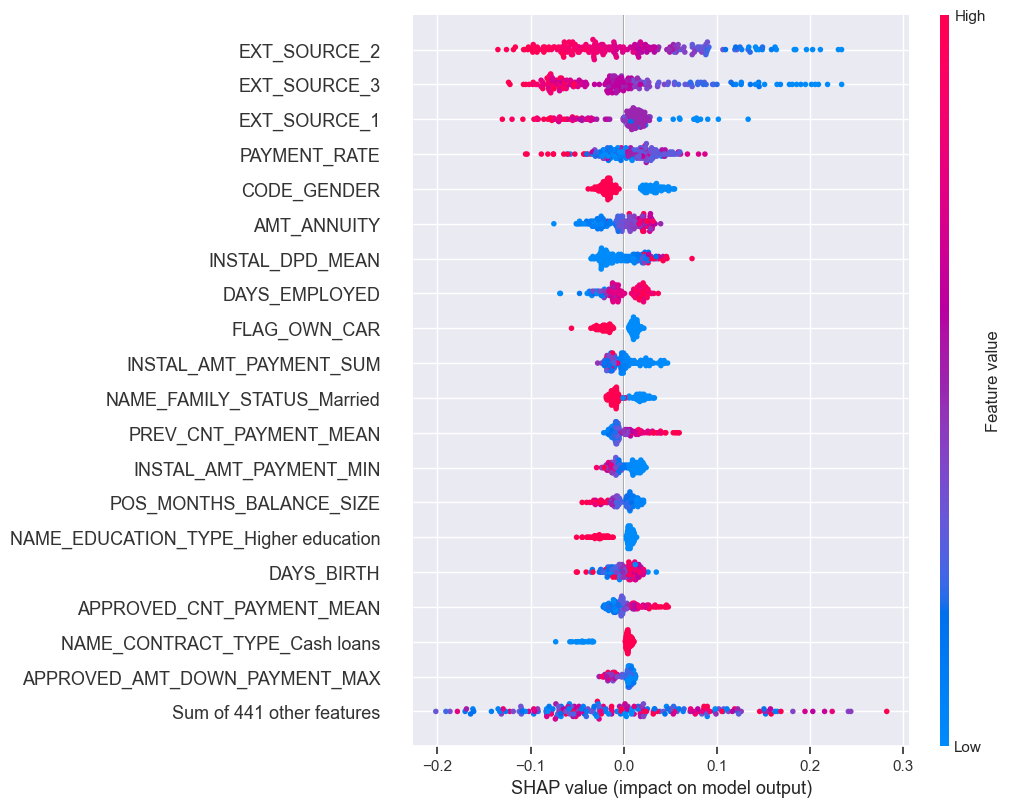

In [71]:
pipe = final_model
imp = pipe.named_steps["imp"]
clf = pipe.named_steps["clf"]

# Préprocessing validation
X_va_imp = imp.transform(X_va)
X_va_imp_df = pd.DataFrame(
    X_va_imp,
    columns=X_va.columns,
    index=X_va.index
)

# Background + sample à expliquer
X_bg = X_va_imp_df.sample(100, random_state=42)
X_explain = X_va_imp_df.sample(200, random_state=42)

# Fonction prédiction
def f(X):
    if not isinstance(X, pd.DataFrame):
        X = pd.DataFrame(X, columns=X_va_imp_df.columns)
    return clf.predict_proba(X)[:, 1]

# Explainer
explainer = shap.Explainer(f, X_bg, algorithm="permutation")

# Règle obligatoire permutation explainer
max_evals = 2 * X_va_imp_df.shape[1] + 1

# Ajout silent=True → supprime progress bars
shap_values = explainer(
    X_explain,
    max_evals=max_evals,
    silent=True
)

# Plot
shap.plots.beeswarm(shap_values, max_display=20) 

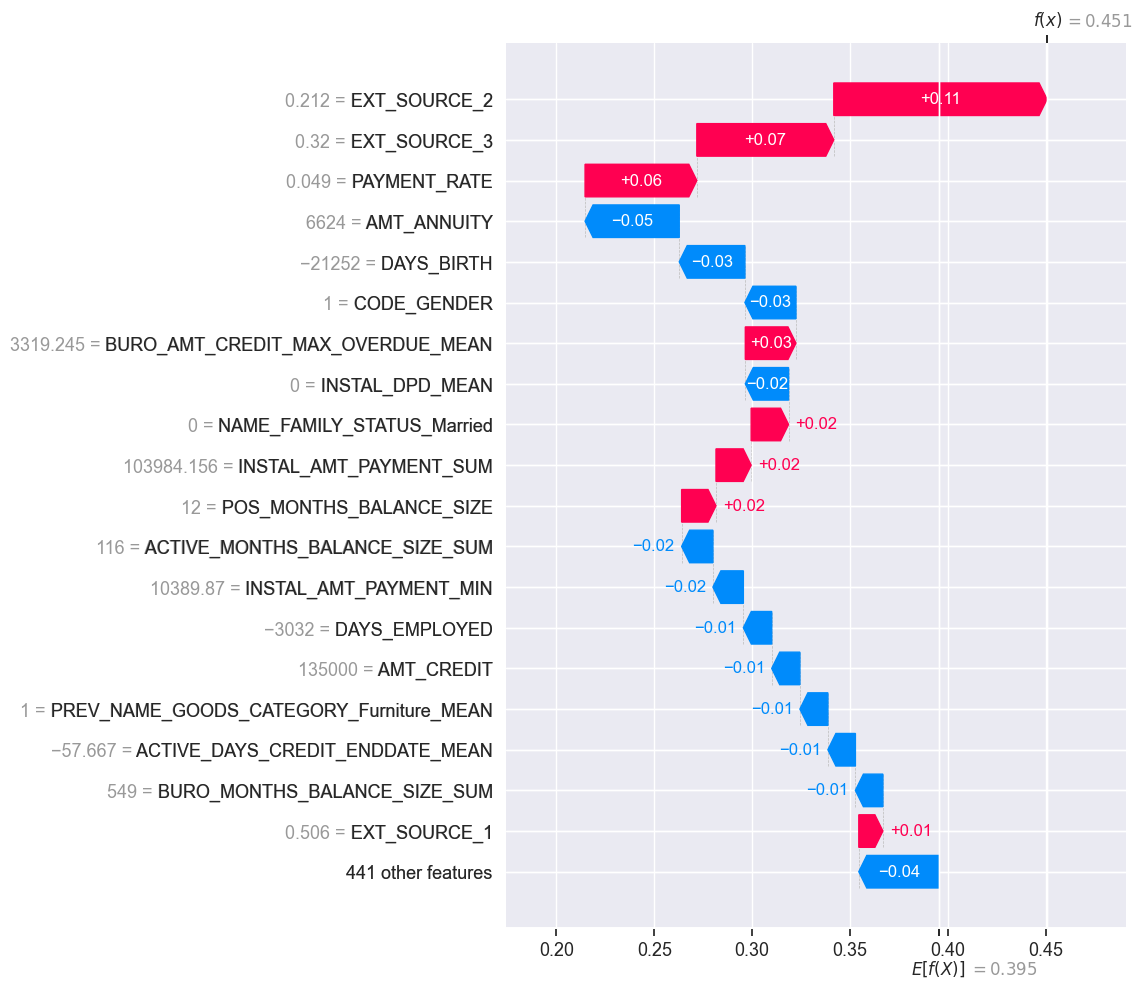

In [64]:
i = 5   # exemple
shap.plots.waterfall(shap_values[i], max_display=20)

In [72]:
Variable                              | Valeur client | Impact SHAP | Sens
------------------------------------------------------------------------------------------------
EXT_SOURCE_2                          | 0.212         | +0.11       | Augmente le risque
EXT_SOURCE_3                          | 0.320         | +0.07       | Augmente le risque
PAYMENT_RATE                          | 0.049         | +0.06       | Augmente le risque
AMT_ANNUITY                           | 6624          | -0.05       | Réduit le risque
DAYS_BIRTH                            | -21252        | -0.03       | Réduit le risque
CODE_GENDER                           | 1             | -0.03       | Réduit le risque
BURO_AMT_CREDIT_MAX_OVERDUE_MEAN      | 3319.245      | +0.03       | Augmente le risque
INSTAL_DPD_MEAN                       | 0             | -0.02       | Réduit le risque
NAME_FAMILY_STATUS_Married            | 0             | +0.02       | Augmente légèrement le risque
INSTAL_AMT_PAYMENT_SUM                | 103984.156    | +0.02       | Augmente légèrement le risque
POS_MONTHS_BALANCE_SIZE               | 12            | +0.02       | Augmente légèrement le risque
ACTIVE_MONTHS_BALANCE_SIZE_SUM        | 116           | -0.02       | Réduit légèrement le risque
INSTAL_AMT_PAYMENT_MIN                | 10389.87      | -0.02       | Réduit légèrement le risque
DAYS_EMPLOYED                         | -3032         | -0.01       | Réduit légèrement le risque
AMT_CREDIT                            | 135000        | -0.01       | Réduit légèrement le risque
PREV_NAME_GOODS_CATEGORY_Furniture    | 1             | -0.01       | Réduit légèrement le risque
ACTIVE_DAYS_CREDIT_ENDDATE_MEAN       | -57.667       | -0.01       | Réduit légèrement le risque
BURO_MONTHS_BALANCE_SIZE_SUM          | 549           | -0.01       | Réduit légèrement le risque
EXT_SOURCE_1                          | 0.506         | +0.01       | Augmente légèrement le risque
------------------------------------------------------------------------------------------------
Autres variables (441)                | —             | -0.04       | Effet cumulé global

SyntaxError: invalid character '—' (U+2014) (373694314.py, line 23)